## 4.1 Import Libraries và Cấu hình

In [1]:
import ast
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu, gaussian_kde, kruskal, shapiro

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import lightgbm as lgb

from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings('ignore')

## 4.2 Tải dữ liệu

In [2]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f'Loaded {len(df):,} tracks')
df.head(3)

Loaded 8,778 tracks


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album


## 4.3 Tiền xử lý dữ liệu

### Quy trình tổng quan

Tiền xử lý được thực hiện theo các bước sau:

1. **Chuyển đổi thời gian**: Chuyển `album_release_date` sang datetime để trích xuất năm
2. **Tạo biến phái sinh**: Thêm `duration_min`, `year` từ dữ liệu gốc
3. **Xử lý giá trị thiếu**: Loại bỏ các bản ghi với giá trị thiếu trong các cột quan trọng
4. **Chuyển đổi kiểu dữ liệu**: Chuyển đổi các cột số về đúng kiểu (int64)

Mỗi câu hỏi sẽ có bước tiền xử lý riêng để tạo tập dữ liệu con phù hợp.

### Bước 1: Chuyển đổi thời gian

In [3]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce')

### Bước 2: Tạo biến phái sinh

In [4]:
df['duration_min'] = df['track_duration_ms'] / 60000
df['year'] = df['album_release_date'].dt.year

### Bước 3: Xử lý giá trị thiếu

In [5]:
df = df.dropna(subset=['year', 'artist_popularity', 'artist_followers'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8772 entries, 0 to 8777
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8772 non-null   object        
 1   track_name          8772 non-null   object        
 2   track_number        8772 non-null   int64         
 3   track_popularity    8772 non-null   int64         
 4   track_duration_ms   8772 non-null   int64         
 5   explicit            8772 non-null   bool          
 6   artist_name         8772 non-null   object        
 7   artist_popularity   8772 non-null   float64       
 8   artist_followers    8772 non-null   float64       
 9   artist_genres       8772 non-null   object        
 10  album_id            8772 non-null   object        
 11  album_name          8772 non-null   object        
 12  album_release_date  8772 non-null   datetime64[ns]
 13  album_total_tracks  8772 non-null   int64         
 1

### Bước 4: Chuyển đổi kiểu dữ liệu

In [6]:
df['artist_popularity'] = df['artist_popularity'].astype('int64')
df['artist_followers'] = df['artist_followers'].astype('int64')
df['year'] = df['year'].astype('int64')

---

## 4.9 Câu hỏi 6: Đặc trưng quan trọng theo từng phân khúc

### Question

Những đặc trưng nào (features) quan trọng nhất thay đổi theo từng cụm (segment) độ nổi tiếng? Liệu mỗi phân khúc popularity có các yếu tố quyết định riêng biệt không?

### A. Tiền xử lý

Chia các bài hát thành 5 phân khúc dựa trên độ phổ biến, sau đó huấn luyện mô hình Random Forest cho từng phân khúc để trích xuất tầm quan trọng của đặc trưng.

In [7]:
q6_df = df.copy()

q6_df['explicit_encoded'] = q6_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q6_df['album_type'], prefix='album', drop_first=False)
q6_df = pd.concat([q6_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q6_df['num_genres'] = q6_df['artist_genres'].apply(count_genres)

q6_df['popularity_segment'] = pd.cut(q6_df['track_popularity'], 
                                      bins=[0, 20, 40, 60, 80, 100],
                                      labels=['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                                              'High (60-80)', 'Very High (80-100)'])

q6_df = q6_df.dropna(subset=['num_genres'])

print(f'Segment distribution:')
print(q6_df['popularity_segment'].value_counts().sort_index())

Segment distribution:
popularity_segment
Very Low (0-20)        578
Low (20-40)           1269
Medium (40-60)        2391
High (60-80)          3396
Very High (80-100)     619
Name: count, dtype: int64


### B. Phân tích

**Phương pháp phân tích:**

Sử dụng các mô hình Random Forest cụ thể cho từng phân khúc để xác định tầm quan trọng của đặc trưng cho mỗi cấp độ phổ biến:

1. **Huấn luyện các mô hình RF riêng biệt**: Một mô hình cho mỗi phân khúc (tổng cộng 5 phân khúc) để nắm bắt các mô hình cụ thể của phân khúc
2. **Trích xuất tầm quan trọng của đặc trưng**: Sử dụng feature_importances_ tích hợp của RF để xếp hạng các đặc trưng theo đóng góp
3. **So sánh giữa các phân khúc**: Trực quan hóa sự thay đổi tầm quan trọng của đặc trưng qua các cấp độ phổ biến

**Các đặc trưng được phân tích:**
- `artist_popularity`: Độ nổi tiếng nghệ sĩ
- `artist_followers`: Quy mô lượng người hâm mộ
- `explicit_encoded`: Xếp hạng nội dung (0/1)
- `album_type_encoded`: Chiến lược phát hành (0/1/2)
- `num_genres`: Sự đa dạng thể loại
- `duration_min`: Độ dài bài hát

**Kết quả mong đợi:**
- Bảng tầm quan trọng của đặc trưng cho mỗi phân khúc
- Biểu đồ nhiệt hiển thị sự biến đổi tầm quan trọng qua các phân khúc
- Biểu đồ cột so sánh các đặc trưng hàng đầu mỗi phân khúc

**Lý do:** Các mức độ phổ biến khác nhau có thể yêu cầu các yếu tố thành công khác nhau - các bài hát ngách (độ phổ biến thấp) có thể dựa vào thời lượng/chất lượng, trong khi các bản hit lan truyền (độ phổ biến cao) yêu cầu danh tiếng nghệ sĩ.

In [8]:
q6_features = ['artist_popularity', 'artist_followers', 'explicit_encoded', 
               'album_album', 'album_compilation', 'album_single',
               'num_genres', 'duration_min'] 
q6_target = 'track_popularity'

q6_importance_results = {}
q6_r2_scores = {}

for segment in q6_df['popularity_segment'].unique():
    segment_data = q6_df[q6_df['popularity_segment'] == segment]
    
    if len(segment_data) < 50:
        continue
    
    X = segment_data[q6_features]
    y = segment_data[q6_target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    importances = pd.Series(rf.feature_importances_, index=q6_features)
    q6_importance_results[segment] = importances
    q6_r2_scores[segment] = rf.score(X_test, y_test)

q6_importance_df = pd.DataFrame(q6_importance_results).T
q6_importance_df

,artist_popularity,artist_followers,explicit_encoded,album_album,album_compilation,album_single,num_genres,duration_min
High (60-80),0.180561,0.289706,0.029723,0.017853,0.008431,0.012508,0.058058,0.403161
Medium (40-60),0.216273,0.323634,0.026759,0.013800,0.022661,0.016172,0.051397,0.329303
Low (20-40),0.230357,0.293139,0.020547,0.017550,0.014129,0.012958,0.052149,0.359172
Very High (80-100),0.223551,0.353872,0.025775,0.012094,0.000205,0.016775,0.039986,0.327741
Very Low (0-20),0.418353,0.209818,0.015907,0.015753,0.032955,0.022675,0.065813,0.218726


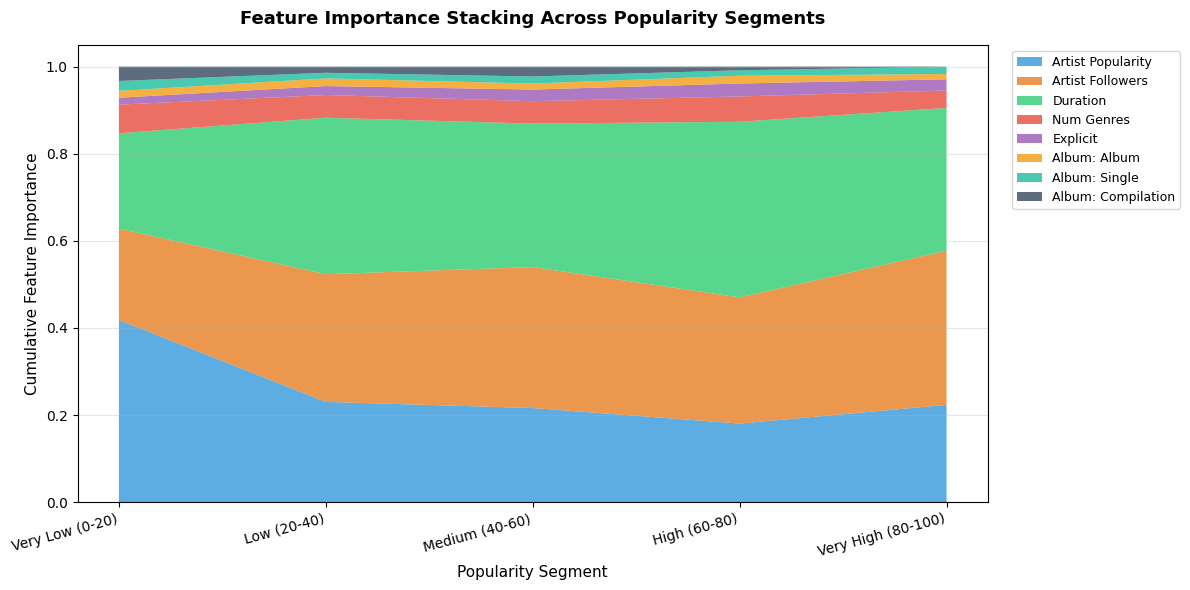

In [9]:
segments_order = ['Very Low (0-20)', 'Low (20-40)', 'Medium (40-60)', 
                  'High (60-80)', 'Very High (80-100)']

q6_plot_df = q6_importance_df.loc[segments_order]

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#34495e']

ax.stackplot(range(len(segments_order)), 
             q6_plot_df['artist_popularity'],
             q6_plot_df['artist_followers'],
             q6_plot_df['duration_min'],
             q6_plot_df['num_genres'],
             q6_plot_df['explicit_encoded'],
             q6_plot_df['album_album'],
             q6_plot_df['album_single'],
             q6_plot_df['album_compilation'],
             labels=['Artist Popularity', 'Artist Followers', 'Duration', 'Num Genres', 
                     'Explicit', 'Album: Album', 'Album: Single', 'Album: Compilation'],
             colors=colors,
             alpha=0.8)

ax.set_xticks(range(len(segments_order)))
ax.set_xticklabels(segments_order, rotation=15, ha='right')
ax.set_ylabel('Cumulative Feature Importance', fontsize=11)
ax.set_xlabel('Popularity Segment', fontsize=11)
ax.set_title('Feature Importance Stacking Across Popularity Segments', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_feature_importance_stacked.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

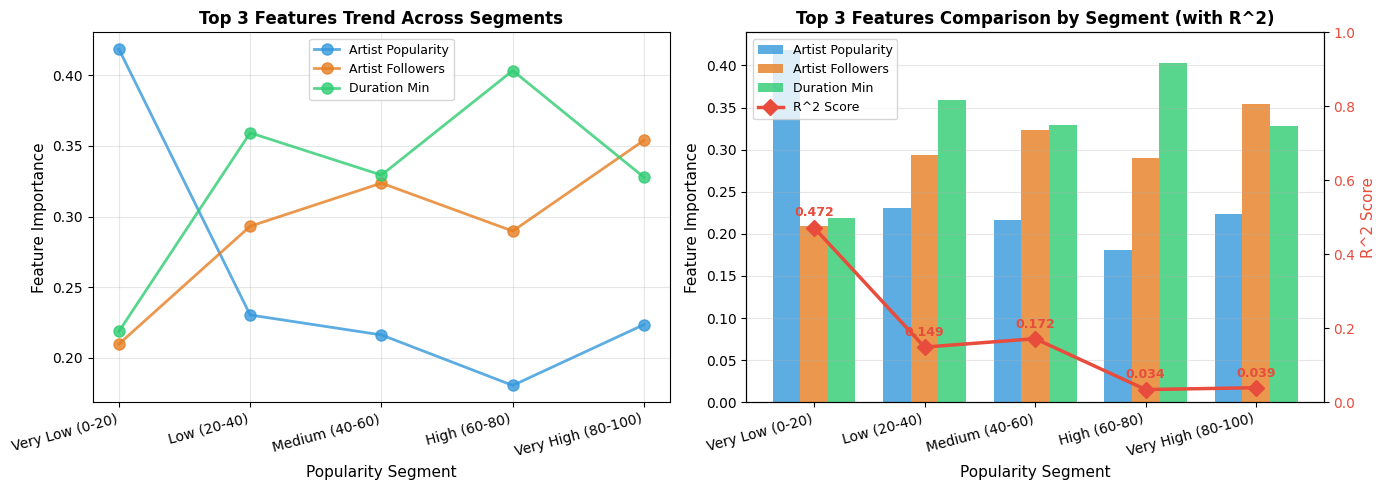

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_features = ['artist_popularity', 'artist_followers', 'duration_min']
colors_map = {'artist_popularity': '#3498db', 
              'artist_followers': '#e67e22', 
              'duration_min': '#2ecc71'}

for feature in top_features:
    axes[0].plot(range(len(segments_order)), q6_plot_df[feature], 
                 marker='o', linewidth=2, markersize=8, 
                 label=feature.replace('_', ' ').title(), 
                 color=colors_map[feature], alpha=0.8)

axes[0].set_xticks(range(len(segments_order)))
axes[0].set_xticklabels(segments_order, rotation=15, ha='right')
axes[0].set_ylabel('Feature Importance', fontsize=11)
axes[0].set_xlabel('Popularity Segment', fontsize=11)
axes[0].set_title('Top 3 Features Trend Across Segments', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='both', alpha=0.3)

x_pos = np.arange(len(segments_order))
width = 0.25

for idx, feature in enumerate(top_features):
    axes[1].bar(x_pos + idx * width, q6_plot_df[feature], width, 
                label=feature.replace('_', ' ').title(), 
                color=colors_map[feature], alpha=0.8)

r2_values = [q6_r2_scores[seg] for seg in segments_order]
ax2 = axes[1].twinx()
ax2.plot(x_pos + width, r2_values, color='#e74c3c', marker='D', linewidth=2.5, 
         markersize=8, label='R^2 Score', zorder=10)
ax2.set_ylabel('R^2 Score', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, 1)

for i, r2 in enumerate(r2_values):
    ax2.text(x_pos[i] + width, r2 + 0.03, f'{r2:.3f}', 
             ha='center', fontsize=9, color='#e74c3c', fontweight='bold')

axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(segments_order, rotation=15, ha='right')
axes[1].set_ylabel('Feature Importance', fontsize=11)
axes[1].set_xlabel('Popularity Segment', fontsize=11)
axes[1].set_title('Top 3 Features Comparison by Segment (with R^2)', fontsize=12, fontweight='bold')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('q6_top_features_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Mỗi phân khúc độ phổ biến có các yếu tố thành công hoàn toàn khác nhau - không có công thức chung.

**Phát hiện chính:**

Phân khúc Rất thấp (0-20): Artist_popularity chiếm 42% tầm quan trọng. Mô hình đạt R^2=0.472, nghĩa là độ phổ biến ở cấp độ này khá dễ dự đoán - nếu nghệ sĩ không nổi thì bài hát cũng khó lên.

Phân khúc Trung bình (20-60): Duration_min (33-36%) và artist_followers (29-32%) trở thành yếu tố chính. R^2 giảm xuống 0.15-0.17, cho thấy đây là vùng cạnh tranh với nhiều yếu tố khác ảnh hưởng.

Phân khúc Cao và Rất cao (60-100): Artist_followers lên top (29-35%), duration_min vẫn mạnh (33-40%). Quan trọng nhất: R2 sụt xuống chỉ còn 0.031-0.039 - gần như không thể dự đoán được độ phổ biến ở cấp độ này với dữ liệu hiện có.

**Thông tin quan trọng về R2:** Mô hình giảm dần từ 0.472 xuống 0.039 chứng tỏ càng lên cao, thành công càng khó đoán. Cần khoảnh khắc lan truyền, chiến dịch tiếp thị, thời điểm may mắn mà dữ liệu không có.

**Ý nghĩa thực tiễn:**

Nghệ sĩ mới (Rất thấp): Tập trung xây dựng artist_popularity trước, hợp tác, chạy danh sách phát.

Nghệ sĩ tầm trung: Tối ưu hóa thời lượng và tăng lượng người theo dõi, chất lượng.

Nghệ sĩ đã thành danh muốn lên top: Nền tảng tốt là cần nhưng không đủ, phải chấp nhận yếu tố may mắn, vì R2=0.03 nghĩa là 97% phương sai không giải thích được bởi dữ liệu.

**Hạn chế:**

R2 thấp ở các phân khúc cao cho thấy thiếu các đặc trưng quan trọng như ngân sách tiếp thị, vị trí danh sách phát, yếu tố lan truyền. Kích thước mẫu nhỏ ở các phân khúc cực đoan có thể ảnh hưởng độ tin cậy.

---

## 4.10 Câu hỏi 7: Machine Learning - Dự đoán Track Popularity

### Question

Xây dựng models để predict track popularity. So sánh performance của các algorithms khác nhau (Linear Regression, XGBoost, Random Forest, Gradient Boosting, Extra Trees, LightGBM) để tìm model tốt nhất.

### A. Tiền xử lý

**Feature Engineering:**
- Mã hóa one-hot cho `album_type` (album, compilation, single) để tránh thiên kiến thứ tự
- Encode `explicit` thành 0/1
- Tính số lượng thể loại của artist (`num_genres`)
- Tính tổng số bài hát của artist (`artist_total_tracks`)
- Tính số bài hát explicit của artist (`explicit_per_artist`)

**Features cuối cùng:** artist_popularity, artist_followers, explicit_encoded, album_album, album_compilation, album_single, duration_min, num_genres, artist_total_tracks, album_total_tracks, explicit_per_artist

**Train/Test Split:** 80/20 với random_state=42

**Scaling:**
- MinMaxScaler cho `artist_popularity` (giữ phạm vi 0-100 tương đối)
- StandardScaler cho các features còn lại (chuẩn hóa về mean=0, std=1)

In [11]:
q7_df = df.copy()

q7_df['explicit_encoded'] = q7_df['explicit'].astype(int)

album_dummies = pd.get_dummies(q7_df['album_type'], prefix='album', drop_first=False)
q7_df = pd.concat([q7_df, album_dummies], axis=1)

def count_genres(genre_str):
    if pd.isna(genre_str) or genre_str == '[]':
        return 0
    try:
        genres = ast.literal_eval(genre_str)
        return len(genres) if isinstance(genres, list) else 0
    except:
        return 0

q7_df['num_genres'] = q7_df['artist_genres'].apply(count_genres)
q7_df = q7_df.dropna(subset=['num_genres'])

artist_track_count = q7_df.groupby('artist_name')['track_id'].count().reset_index()
artist_track_count.columns = ['artist_name', 'artist_total_tracks']

explicit_per_artist = q7_df.groupby('artist_name')['explicit_encoded'].sum().reset_index()
explicit_per_artist.columns = ['artist_name', 'explicit_per_artist']

q7_df = q7_df.merge(artist_track_count, on='artist_name', how='left')
q7_df = q7_df.merge(explicit_per_artist, on='artist_name', how='left')

q7_df['random_gaussian'] = np.random.normal(0, 1, size=len(q7_df))

q7_features = ['artist_popularity', 'artist_followers', 'explicit_encoded',
               'album_album', 'album_compilation', 'album_single', 
               'duration_min', 'num_genres', 'artist_total_tracks', 
               'album_total_tracks', 'explicit_per_artist'] 
               
q7_target = 'track_popularity'

X = q7_df[q7_features]
y = q7_df[q7_target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

artist_pop_train = X_train[['artist_popularity']].copy()
artist_pop_test = X_test[['artist_popularity']].copy()

other_features = [col for col in X_train.columns if col != 'artist_popularity']
X_train_other = X_train[other_features].copy()
X_test_other = X_test[other_features].copy()

minmax_scaler = MinMaxScaler()
artist_pop_train_scaled = minmax_scaler.fit_transform(artist_pop_train)
artist_pop_test_scaled = minmax_scaler.transform(artist_pop_test)

scaler = StandardScaler()
X_train_other_scaled = scaler.fit_transform(X_train_other)
X_test_other_scaled = scaler.transform(X_test_other)

X_train_scaled = pd.DataFrame(X_train_other_scaled, columns=other_features, index=X_train.index)
X_train_scaled['artist_popularity'] = artist_pop_train_scaled

X_test_scaled = pd.DataFrame(X_test_other_scaled, columns=other_features, index=X_test.index)
X_test_scaled['artist_popularity'] = artist_pop_test_scaled

X_train = X_train_scaled[X.columns]
X_test = X_test_scaled[X.columns]

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (7017, 11)
X_test shape: (1755, 11)
y_train shape: (7017,)
y_test shape: (1755,)


### B. Phân tích

**Phương pháp phân tích:**

So sánh hiệu suất của 6 thuật toán ML trên tác vụ dự đoán độ phổ biến bài hát:

1. **Hồi quy tuyến tính (Linear Regression)** (cơ sở): Mô hình đơn giản để thiết lập hiệu suất cơ sở. Giả định mối quan hệ tuyến tính giữa các đặc trưng và mục tiêu.

2. **XGBoost**: Extreme Gradient Boosting, một thuật toán boosting mạnh mẽ với regularization tích hợp.

3. **Rừng ngẫu nhiên (Random Forest)**: Tập hợp các cây quyết định với kỹ thuật bagging.

4. **Gradient Boosting**: Tập hợp tuần tự, mỗi cây học từ lỗi của cây trước.

5. **Extra Trees**: Tương tự Random Forest nhưng phân chia các nút ngẫu nhiên thay vì tìm phân chia tốt nhất.

6. **LightGBM**: Gradient boosting được tối ưu hóa cho tốc độ và hiệu quả bộ nhớ.

**Quy trình làm việc:**

**Approach 1: Train toàn bộ dữ liệu**
- Chia dữ liệu 80/20 train/test với random_state=42 để tái lập
- Huấn luyện 6 mô hình với 10-fold cross-validation
- Đánh giá trên tập kiểm tra với 3 chỉ số: $R^2$ score, MAE, RMSE
- Kết hợp các mô hình bằng Ensemble (Simple Average và Weighted Average)

**Approach 2: Clustering-based models**
- Áp dụng K-Means clustering (K=3) trên toàn bộ dữ liệu để phân chia thành các nhóm đặc trưng
- Huấn luyện mô hình riêng cho từng cluster, giả định mỗi nhóm có mối quan hệ dự đoán khác biệt
- So sánh với approach train chung để đánh giá hiệu quả của phân cụm

**Kết quả mong đợi:**
- Bảng so sánh các chỉ số giữa các mô hình và approaches
- Biểu đồ cột so sánh $R^2$/MAE/RMSE giữa các mô hình
- Biểu đồ phân tán: thực tế so với dự đoán (mô hình tốt nhất)
- Biểu đồ tầm quan trọng của đặc trưng (các mô hình dựa trên cây)
- Visualization PCA 2D/3D để quan sát phân bố clusters

In [12]:
SEED = 422
N_FOLDS = 10

model_configs = {
    'Linear Regression': {
        'class': LinearRegression,
        'params': {}
    },
    'XGBoost': {
        'class': XGBRegressor,
        'params': {'n_estimators': 100, 'max_depth': 4, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0}
    },
    'Random Forest': {
        'class': RandomForestRegressor,
        'params': {'n_estimators': 100, 'max_depth': 10, 'random_state': SEED, 'n_jobs': -1}
    },
    'Gradient Boosting': {
        'class': GradientBoostingRegressor,
        'params': {'n_estimators': 70, 'max_depth': 5, 'random_state': SEED}
    },
    'Extra Trees': {
        'class': ExtraTreesRegressor,
        'params': {'n_estimators': 50, 'max_depth':15, 'random_state': SEED, 'n_jobs': -1}
    },
    'LightGBM': {
        'class': lgb.LGBMRegressor,
        'params': {'n_estimators': 100, 'max_depth': 5, 'random_state': SEED, 'verbose': -1}
    }
}

q7_results = {}
q7_metrics_data = []

print(f'Training với {len(X_train):,} samples (train) + {len(X_test):,} hold-out test')
print(f'Sử dụng {N_FOLDS}-fold CV trên training set với seed={SEED}')
print(f'Target mean: {y_train.mean():.2f}, std: {y_train.std():.2f}')
print(f'Test target mean: {y_test.mean():.2f}, std: {y_test.std():.2f}\n')

for name, config in model_configs.items():
    print(f'Training {name}', end=' ')
    
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    val_r2_scores = []
    val_mae_scores = []
    val_rmse_scores = []
    
    # K-Fold CV với cùng hyperparameters
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Tạo model instance với cùng config
        fold_model = config['class'](**config['params'])
        fold_model.fit(X_fold_train, y_fold_train)
        y_val_pred = fold_model.predict(X_fold_val)
        
        val_r2_scores.append(r2_score(y_fold_val, y_val_pred))
        val_mae_scores.append(mean_absolute_error(y_fold_val, y_val_pred))
        val_rmse_scores.append(np.sqrt(mean_squared_error(y_fold_val, y_val_pred)))
    
    avg_val_r2 = np.mean(val_r2_scores)
    std_val_r2 = np.std(val_r2_scores)
    avg_val_mae = np.mean(val_mae_scores)
    avg_val_rmse = np.mean(val_rmse_scores)
    
    print(f'Val R2: {avg_val_r2:.2f} (std: {std_val_r2:.2f})')
    
    # Train trên toàn bộ train set với cùng hyperparameters
    final_model = config['class'](**config['params'])
    final_model.fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)
    
    test_r2 = r2_score(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    q7_results[name] = {
        'model': final_model,
        'predictions': y_test_pred
    }
    
    q7_metrics_data.append({
        'Model': name,
        f'Val R^2 ({N_FOLDS}-fold)': avg_val_r2,
        'Val R^2 Std': std_val_r2,
        f'Val MAE ({N_FOLDS}-fold)': avg_val_mae,
        f'Val RMSE ({N_FOLDS}-fold)': avg_val_rmse,
        'Test R^2': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse
    })

q7_metrics_df = pd.DataFrame(q7_metrics_data).set_index('Model')
q7_metrics_df

Training với 7,017 samples (train) + 1,755 hold-out test
Sử dụng 10-fold CV trên training set với seed=422
Target mean: 52.31, std: 24.05
Test target mean: 51.96, std: 24.14

Training Linear Regression Val R2: 0.25 (std: 0.03)
Training XGBoost Val R2: 0.31 (std: 0.03)
Training Random Forest Val R2: 0.33 (std: 0.03)
Training Gradient Boosting Val R2: 0.32 (std: 0.03)
Training Extra Trees Val R2: 0.32 (std: 0.04)
Training LightGBM Val R2: 0.32 (std: 0.03)


,Val R^2 (10-fold),Val R^2 Std,Val MAE (10-fold),Val RMSE (10-fold),Test R^2,Test MAE,Test RMSE
Model,,,,,,,
Linear Regression,0.247905,0.027522,15.590526,20.834189,0.266076,15.492175,20.674076
XGBoost,0.305837,0.026445,14.344764,20.015406,0.335108,14.191945,19.677780
Random Forest,0.326508,0.028958,14.198489,19.715141,0.351970,14.080961,19.426658
Gradient Boosting,0.320680,0.026713,14.337259,19.800271,0.348077,14.119382,19.484922
Extra Trees,0.316147,0.041134,13.971972,19.861647,0.337142,13.885328,19.647661
LightGBM,0.319573,0.028751,14.305053,19.815313,0.350530,14.086811,19.448228


Kết hợp predictions của các mô hình bằng Simple Average và Weighted Average (dựa trên Val R²) để cải thiện độ chính xác dự đoán.

In [13]:
# Lấy predictions của tất cả models
all_predictions = np.array([q7_results[name]['predictions'] for name in model_configs.keys()])

# Method 1: Simple Average (Equal Weight)
ensemble_pred_avg = np.mean(all_predictions, axis=0)

test_r2_avg = r2_score(y_test, ensemble_pred_avg)
test_mae_avg = mean_absolute_error(y_test, ensemble_pred_avg)
test_rmse_avg = np.sqrt(mean_squared_error(y_test, ensemble_pred_avg))

# Method 2: Weighted Average (dựa trên Validation R^2 scores)
val_r2_scores = [q7_metrics_df.loc[name, f'Val R^2 ({N_FOLDS}-fold)'] for name in model_configs.keys()]
# Chuyển negative R^2 thành 0 để tránh weight âm
val_r2_scores = np.maximum(val_r2_scores, 0)
weights = np.array(val_r2_scores) / np.sum(val_r2_scores)

ensemble_pred_weighted = np.average(all_predictions, axis=0, weights=weights)

test_r2_weighted = r2_score(y_test, ensemble_pred_weighted)
test_mae_weighted = mean_absolute_error(y_test, ensemble_pred_weighted)
test_rmse_weighted = np.sqrt(mean_squared_error(y_test, ensemble_pred_weighted))

# Thêm vào metrics dataframe
ensemble_metrics = pd.DataFrame([
    {
        'Model': 'Ensemble (Simple Avg)',
        f'Val R^2 ({N_FOLDS}-fold)': np.nan,
        'Val R^2 Std': np.nan,
        f'Val MAE ({N_FOLDS}-fold)': np.nan,
        f'Val RMSE ({N_FOLDS}-fold)': np.nan,
        'Test R^2': test_r2_avg,
        'Test MAE': test_mae_avg,
        'Test RMSE': test_rmse_avg
    },
    {
        'Model': 'Ensemble (Weighted Avg)',
        f'Val R^2 ({N_FOLDS}-fold)': np.nan,
        'Val R^2 Std': np.nan,
        f'Val MAE ({N_FOLDS}-fold)': np.nan,
        f'Val RMSE ({N_FOLDS}-fold)': np.nan,
        'Test R^2': test_r2_weighted,
        'Test MAE': test_mae_weighted,
        'Test RMSE': test_rmse_weighted
    }
]).set_index('Model')

q7_metrics_df_with_ensemble = pd.concat([q7_metrics_df, ensemble_metrics])

q7_metrics_df_with_ensemble

,Val R^2 (10-fold),Val R^2 Std,Val MAE (10-fold),Val RMSE (10-fold),Test R^2,Test MAE,Test RMSE
Model,,,,,,,
Linear Regression,0.247905,0.027522,15.590526,20.834189,0.266076,15.492175,20.674076
XGBoost,0.305837,0.026445,14.344764,20.015406,0.335108,14.191945,19.677780
Random Forest,0.326508,0.028958,14.198489,19.715141,0.351970,14.080961,19.426658
Gradient Boosting,0.320680,0.026713,14.337259,19.800271,0.348077,14.119382,19.484922
Extra Trees,0.316147,0.041134,13.971972,19.861647,0.337142,13.885328,19.647661
LightGBM,0.319573,0.028751,14.305053,19.815313,0.350530,14.086811,19.448228
Ensemble (Simple Avg),NaN,NaN,NaN,NaN,0.361574,14.035164,19.282167
Ensemble (Weighted Avg),NaN,NaN,NaN,NaN,0.362591,14.002097,19.266803


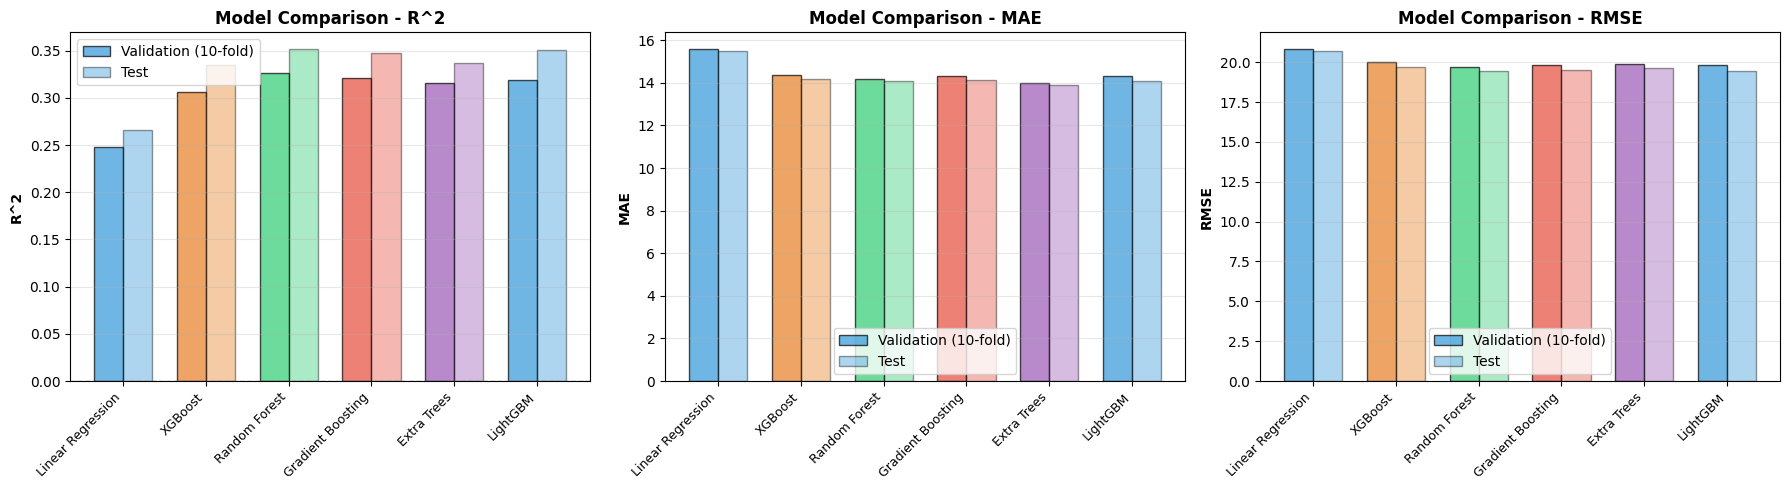

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['R^2', 'MAE', 'RMSE']
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, metric in enumerate(metrics):
    val_col = f'Val {metric} ({N_FOLDS}-fold)'
    test_col = f'Test {metric}'
    
    x_pos = np.arange(len(q7_metrics_df))
    width = 0.35
    
    axes[idx].bar(x_pos - width/2, q7_metrics_df[val_col], width, 
                  label=f'Validation ({N_FOLDS}-fold)', color=colors, alpha=0.7, edgecolor='black')
    axes[idx].bar(x_pos + width/2, q7_metrics_df[test_col], width, 
                  label='Test', color=colors, alpha=0.4, edgecolor='black')
    
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(q7_metrics_df.index, rotation=45, ha='right', fontsize=9)
    axes[idx].set_ylabel(metric, fontweight='bold')
    axes[idx].set_title(f'Model Comparison - {metric}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    
    if metric == 'R^2':
        axes[idx].axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('q7_model_comparison.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

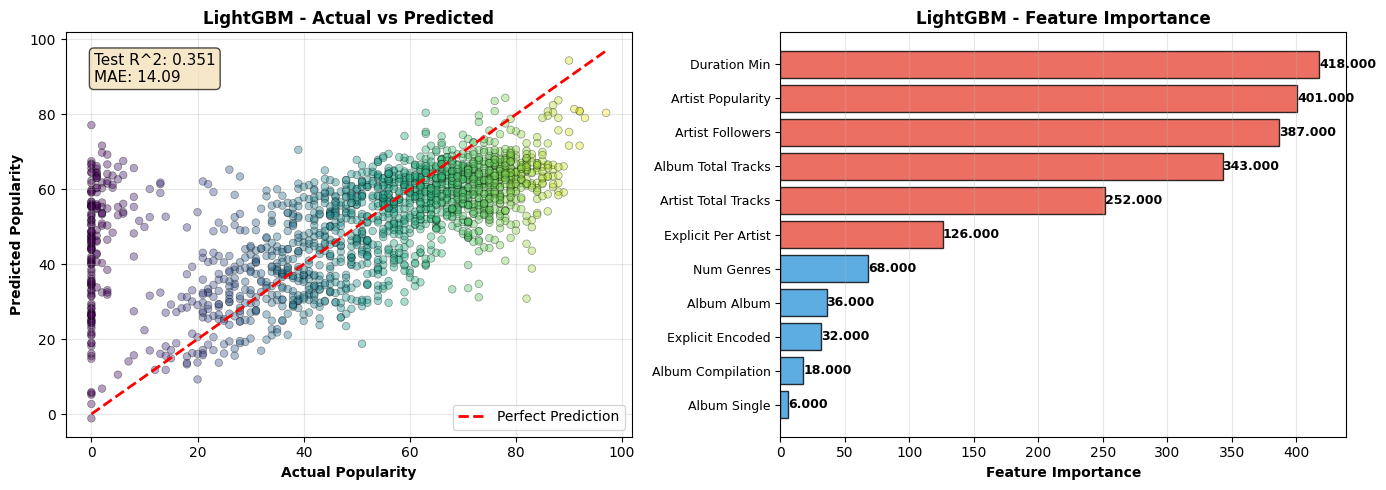

In [15]:
best_model_name = 'LightGBM'
best_model = q7_results[best_model_name]['model']
best_predictions = q7_results[best_model_name]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_predictions, alpha=0.4, s=30, c=y_test, cmap='viridis', edgecolors='black', linewidths=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

axes[0].set_xlabel('Actual Popularity', fontweight='bold')
axes[0].set_ylabel('Predicted Popularity', fontweight='bold')
axes[0].set_title(f'{best_model_name} - Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

test_r2 = q7_metrics_df.loc[best_model_name, 'Test R^2']
test_mae = q7_metrics_df.loc[best_model_name, 'Test MAE']
axes[0].text(0.05, 0.95, f'Test R^2: {test_r2:.3f}\nMAE: {test_mae:.2f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

importances = pd.Series(best_model.feature_importances_, index=q7_features).sort_values(ascending=True)
colors_importance = ['#3498db' if x < importances.median() else '#e74c3c' for x in importances]

axes[1].barh(range(len(importances)), importances.values, color=colors_importance, alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(importances)))
axes[1].set_yticklabels([label.replace('_', ' ').title() for label in importances.index], fontsize=9)
axes[1].set_xlabel('Feature Importance', fontweight='bold')
axes[1].set_title(f'{best_model_name} - Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(importances.values):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('q7_best_model_analysis.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

Nhận thấy dữ liệu có thể có các nhóm đặc trưng khác nhau (ví dụ: các thể loại nhạc, nhóm độ tuổi người nghe), ta thử áp dụng K-Means clustering để phân chia dữ liệu thành các cụm, sau đó train mô hình riêng cho từng cụm nhằm cải thiện độ chính xác dự đoán.

In [16]:
# Gộp train và test để cluster (unsupervised learning)
from sklearn.mixture import GaussianMixture
X_full = pd.concat([X_train, X_test], axis=0)

# Thực hiện K-Means với K=3
SEED = 42
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=50, init="k-means++")
cluster_labels_full = kmeans.fit_predict(X_full)

# Split cluster labels về train và test
cluster_labels_train = cluster_labels_full[:len(X_train)]
cluster_labels_test = cluster_labels_full[len(X_train):]

# Thêm cluster labels vào dataframe
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels_train
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = cluster_labels_test

# Thống kê phân bố clusters
print(f"\nPhân bố clusters trong Training set:")
for i in range(N_CLUSTERS):
    count = np.sum(cluster_labels_train == i)
    percentage = count / len(cluster_labels_train) * 100
    print(f"  Cluster {i}: {count:,} samples ({percentage:.1f}%)")

print(f"\nPhân bố clusters trong Test set:")
for i in range(N_CLUSTERS):
    count = np.sum(cluster_labels_test == i)
    percentage = count / len(cluster_labels_test) * 100
    print(f"  Cluster {i}: {count:,} samples ({percentage:.1f}%)")


Phân bố clusters trong Training set:
  Cluster 0: 4,525 samples (64.5%)
  Cluster 1: 1,793 samples (25.6%)
  Cluster 2: 699 samples (10.0%)

Phân bố clusters trong Test set:
  Cluster 0: 1,175 samples (67.0%)
  Cluster 1: 416 samples (23.7%)
  Cluster 2: 164 samples (9.3%)


In [17]:
# Gộp train và test để cluster (unsupervised learning)
from sklearn.mixture import GaussianMixture
X_full = pd.concat([X_train, X_test], axis=0)

# Thực hiện K-Means với K=3
SEED = 42
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=50, init="k-means++")
cluster_labels_full = kmeans.fit_predict(X_full)

# Split cluster labels về train và test
cluster_labels_train = cluster_labels_full[:len(X_train)]
cluster_labels_test = cluster_labels_full[len(X_train):]

# Thêm cluster labels vào dataframe
X_train_clustered = X_train.copy()
X_train_clustered['cluster'] = cluster_labels_train
X_test_clustered = X_test.copy()
X_test_clustered['cluster'] = cluster_labels_test

# Tạo DataFrame thống kê phân bố clusters
cluster_stats = []
for i in range(N_CLUSTERS):
    train_count = np.sum(cluster_labels_train == i)
    test_count = np.sum(cluster_labels_test == i)
    train_pct = train_count / len(cluster_labels_train) * 100
    test_pct = test_count / len(cluster_labels_test) * 100
    cluster_stats.append({
        'Cluster': i,
        'Train Count': train_count,
        'Train %': f'{train_pct:.1f}%',
        'Test Count': test_count,
        'Test %': f'{test_pct:.1f}%'
    })

cluster_distribution = pd.DataFrame(cluster_stats)
cluster_distribution

,Cluster,Train Count,Train %,Test Count,Test %
0,0,4525,64.5%,1175,67.0%
1,1,1793,25.6%,416,23.7%
2,2,699,10.0%,164,9.3%


In [18]:
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train)

pca_3d = PCA(n_components=3, random_state=SEED)
X_pca_3d = pca_3d.fit_transform(X_train)

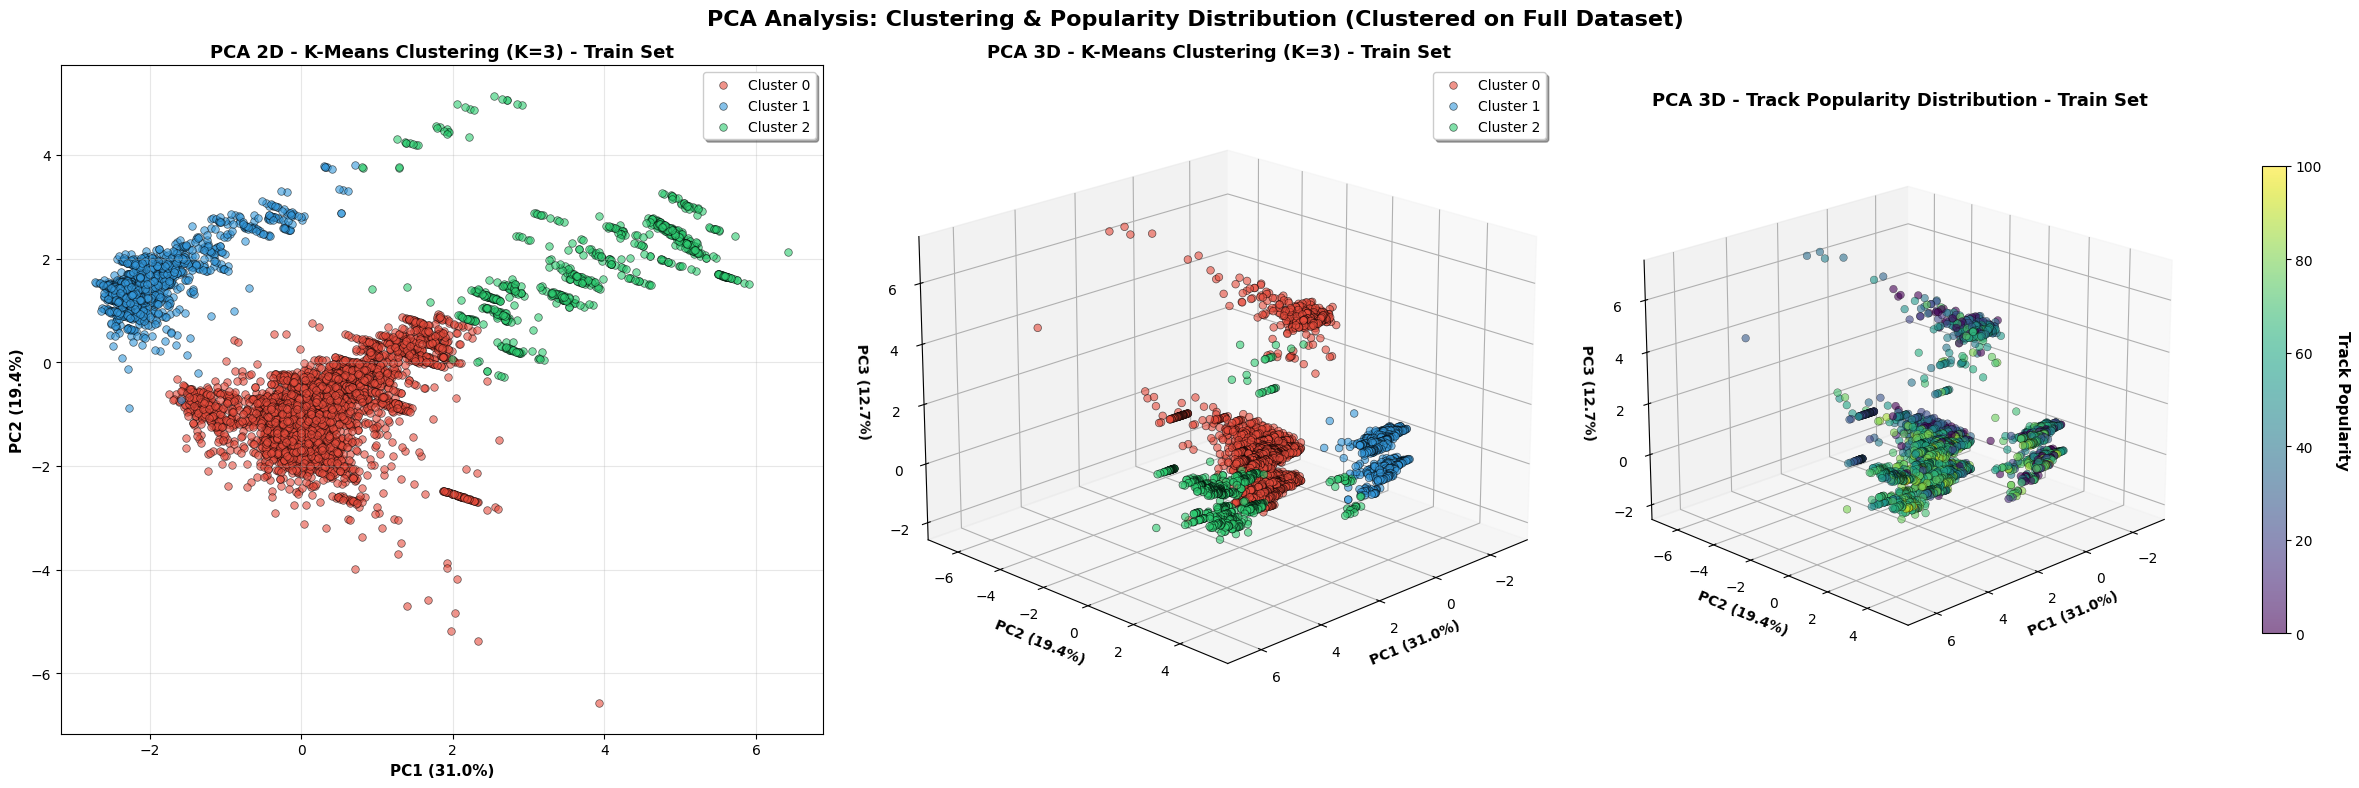

In [19]:
fig = plt.figure(figsize=(24, 8))

scatter_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
popularity_values = y_train.values

# PCA 2D với cluster colors
ax1 = fig.add_subplot(1, 3, 1)
for i in range(N_CLUSTERS):
    mask = cluster_labels_train == i
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                c=scatter_colors[i], label=f'Cluster {i}', 
                alpha=0.6, edgecolors='k', linewidth=0.5, s=30)

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=11)
ax1.set_title(f'PCA 2D - K-Means Clustering (K={N_CLUSTERS}) - Train Set', fontweight='bold', fontsize=13)
ax1.legend(loc='best', frameon=True, shadow=True)
ax1.grid(alpha=0.3)

# PCA 3D với cluster colors
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
for i in range(N_CLUSTERS):
    mask = cluster_labels_train == i
    ax2.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
                c=scatter_colors[i], label=f'Cluster {i}', 
                alpha=0.6, edgecolors='k', linewidth=0.5, s=30)

ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=10)
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontweight='bold', fontsize=10)
ax2.set_title(f'PCA 3D - K-Means Clustering (K={N_CLUSTERS}) - Train Set', fontweight='bold', fontsize=13)
ax2.legend(loc='best', frameon=True, shadow=True)
ax2.view_init(elev=20, azim=45)
ax2.grid(alpha=0.3)

# PCA 3D với popularity colorbar
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
scatter = ax3.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                      c=popularity_values, cmap='viridis', alpha=0.6,
                      edgecolors='k', linewidth=0.3, s=30)

cbar = plt.colorbar(scatter, ax=ax3, pad=0.1, shrink=0.7)
cbar.set_label('Track Popularity', fontweight='bold', fontsize=11, rotation=270, labelpad=20)

ax3.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontweight='bold', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontweight='bold', fontsize=10)
ax3.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontweight='bold', fontsize=10)
ax3.set_title('PCA 3D - Track Popularity Distribution - Train Set', fontweight='bold', fontsize=13)
ax3.view_init(elev=20, azim=45)
ax3.grid(alpha=0.3)

fig.suptitle(f'PCA Analysis: Clustering & Popularity Distribution (Clustered on Full Dataset)', 
             fontweight='bold', fontsize=16, y=0.98)

plt.tight_layout()
plt.savefig('pca_combined_visualization.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

In [20]:
SEED = 422
N_FOLDS = 10

model_configs = {
    'Linear Regression': {'class': LinearRegression, 'params': {}},
    'XGBoost': {'class': XGBRegressor, 'params': {'n_estimators': 100, 'max_depth': 4, 'random_state': SEED, 'n_jobs': -1, 'verbosity': 0}},
    'Random Forest': {'class': RandomForestRegressor, 'params': {'n_estimators': 100, 'max_depth': 15, 'random_state': SEED, 'n_jobs': -1}},
    'Gradient Boosting': {'class': GradientBoostingRegressor, 'params': {'n_estimators': 70, 'max_depth': 5, 'random_state': SEED}},
    'Extra Trees': {'class': ExtraTreesRegressor, 'params': {'n_estimators': 100, 'max_depth': 35, 'random_state': SEED, 'n_jobs': -1}},
    'LightGBM': {'class': lgb.LGBMRegressor, 'params': {'n_estimators': 100, 'max_depth': 5, 'random_state': SEED, 'verbose': -1}}
}

cluster_models = {name: {} for name in model_configs.keys()}
all_predictions = {name: np.zeros(len(y_test)) for name in model_configs.keys()}
cluster_metrics_detail = []

for cluster_id in range(N_CLUSTERS):
    mask_train = cluster_labels_train == cluster_id
    mask_test = cluster_labels_test == cluster_id
    
    X_train_c = X_train[mask_train]
    y_train_c = y_train[mask_train]
    X_test_c = X_test[mask_test]
    y_test_c = y_test[mask_test]
    
    if len(X_train_c) < N_FOLDS * 2 or len(X_test_c) == 0:
        continue
    
    for name, cfg in model_configs.items():
        kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
        val_r2 = []
        
        for train_idx, val_idx in kf.split(X_train_c):
            X_fold_train = X_train_c.iloc[train_idx]
            y_fold_train = y_train_c.iloc[train_idx]
            X_fold_val = X_train_c.iloc[val_idx]
            y_fold_val = y_train_c.iloc[val_idx]
            
            fold_model = cfg['class'](**cfg['params'])
            fold_model.fit(X_fold_train, y_fold_train)
            y_fold_pred = fold_model.predict(X_fold_val)
            val_r2.append(r2_score(y_fold_val, y_fold_pred))
        
        model = cfg['class'](**cfg['params'])
        model.fit(X_train_c, y_train_c)
        y_pred_cluster = model.predict(X_test_c)
        
        cluster_models[name][cluster_id] = model
        all_predictions[name][mask_test] = y_pred_cluster
        
        test_r2_cluster = r2_score(y_test_c, y_pred_cluster)
        test_mae_cluster = mean_absolute_error(y_test_c, y_pred_cluster)
        test_rmse_cluster = np.sqrt(mean_squared_error(y_test_c, y_pred_cluster))
        
        cluster_metrics_detail.append({
            'Cluster': cluster_id,
            'Model': name,
            'Val R^2': np.mean(val_r2),
            'Val R^2 Std': np.std(val_r2),
            'Test R^2': test_r2_cluster,
            'Test MAE': test_mae_cluster,
            'Test RMSE': test_rmse_cluster,
            'N_train': len(X_train_c),
            'N_test': len(X_test_c)
        })

In [21]:
# Tính metrics tổng thể cho từng model
clustered_metrics = []

for name in model_configs.keys():
    y_pred_full = all_predictions[name]
    
    # Overall test metrics
    test_r2 = r2_score(y_test, y_pred_full)
    test_mae = mean_absolute_error(y_test, y_pred_full)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_full))
    
    # Average validation metrics across clusters
    model_cluster_metrics = [m for m in cluster_metrics_detail if m['Model'] == name]
    avg_val_r2 = np.mean([m['Val R^2'] for m in model_cluster_metrics])
    avg_val_r2_std = np.mean([m['Val R^2 Std'] for m in model_cluster_metrics])
    
    clustered_metrics.append({
        'Model': name,
        f'Val R^2 ({N_FOLDS}-fold)': avg_val_r2,
        'Val R^2 Std': avg_val_r2_std,
        'Test R^2': test_r2,
        'Test MAE': test_mae,
        'Test RMSE': test_rmse
    })

clustered_models_df = pd.DataFrame(clustered_metrics).set_index('Model')
clustered_models_df

,Val R^2 (10-fold),Val R^2 Std,Test R^2,Test MAE,Test RMSE
Model,,,,,
Linear Regression,0.221482,0.081096,0.286321,15.130029,20.386943
XGBoost,0.165241,0.150458,0.306071,14.347340,20.102868
Random Forest,0.236906,0.113479,0.319923,14.075258,19.901211
Gradient Boosting,0.242225,0.105651,0.338730,14.136598,19.624111
Extra Trees,0.080667,0.197407,0.206184,14.693625,21.501098
LightGBM,0.275026,0.099287,0.342970,14.122009,19.561097


### C. Kết quả & Giải thích

**Câu trả lời:** Sau khi so sánh 6 mô hình khác nhau, **Random Forest, Gradient Boosting và LightGBM** là 3 mô hình tốt nhất với Test $R^2$ = 0.35, vượt trội hơn Linear Regression (0.27), XGBoost (0.34), và Extra Trees (0.34). Cụ thể, Random Forest đạt Test MAE thấp nhất (14.08), trong khi Gradient Boosting và LightGBM có Test MAE lần lượt là 14.12 và 14.09.

**Ensemble (Weighted Average)** kết hợp các mô hình đạt hiệu suất cao nhất với **Test $R^2$ = 0.36, MAE = 14.00, RMSE = 19.27**, cải thiện so với từng mô hình đơn lẻ.

**Phát hiện chính:**

- Các mô hình cây quyết định ($R^2$ ≈ 0.34-0.35) vượt trội hơn hồi quy tuyến tính ($R^2$ = 0.27), cho thấy tồn tại các mối quan hệ phi tuyến tính giữa features và popularity
- Phương pháp kết hợp mô hình giúp cải thiện thêm 1-2% $R^2$ so với mô hình đơn lẻ tốt nhất
- **Phân cụm dữ liệu không cải thiện hiệu suất** (Test $R^2$ giảm xuống 0.32-0.34 so với 0.35-0.36 khi train chung), có thể do chia nhỏ dữ liệu làm giảm hiệu quả training hoặc các cụm không có mối quan hệ dự đoán khác biệt đáng kể

**Biểu đồ phân tán thực tế so với dự đoán:**

Mô hình dự đoán khá chính xác ở vùng popularity trung bình (30-70), khi các điểm dữ liệu phân bố gần đường dự đoán hoàn hảo. Tuy nhiên, mô hình có xu hướng **đánh giá quá cao các bài hát có popularity thấp** (nhiều điểm nằm phía trên đường chéo khi giá trị thực tế gần 0).

**Kết luận:**

Mô hình kết hợp có trọng số (Ensemble Weighted Average) là mô hình tốt nhất cho bài toán dự đoán độ phổ biến của bài hát, với Test $R^2$ = 0.36 và MAE = 14.00. Huấn luyện một mô hình trên toàn bộ dữ liệu tốt hơn phương pháp phân cụm.

**Ý nghĩa thực tiễn:**
- Với $R^2$ = 0.36 và MAE = 14.00, mô hình có thể dùng để xếp hạng, sàng lọc, hoặc phát hiện ngoại lai, nhưng không thể thay thế đánh giá của chuyên gia âm nhạc (A&R)
- 64% phương sai chưa giải thích được, chủ yếu do các yếu tố ngoài dữ liệu như marketing lan truyền, vị trí trong danh sách phát, thời điểm phát hành, và các yếu tố xã hội